In [ ]:
# Загрузим батч из 1000 примеров на сложение из тренеровочного сета.
# На основе него сформулируем батч с операндами, поменянными местами.

In [4]:
import json
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from grokking_carries.config import ModelConfig
from grokking_carries.model.transformer import GrokkingCarriesTransformer
from grokking_carries.data.tokenizer import MathTokenizer

model_cfg = ModelConfig()
model = GrokkingCarriesTransformer(model_cfg)
tokenizer = MathTokenizer()


test_file_path = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "test.jsonl"))
print(f"Чтение тестового сета из:\n{test_file_path}")

normal_sequences = []
mirrored_sequences = []

with open(test_file_path, "r", encoding="utf-8") as f:
    for line in f:
        record = json.loads(line)
        prompt = record['prompt']   
        target = record['target']   
        
        # Фильтруем только сложение
        if '+' in prompt:
            tokens_pool = prompt.strip().split(" ")
            plus_idx = tokens_pool.index('+')
            eq_idx = tokens_pool.index('=')
            
            operand_a = tokens_pool[:plus_idx]
            operand_b = tokens_pool[plus_idx+1:eq_idx]
            
            mirrored_prompt = " ".join(operand_b) + " + " + " ".join(operand_a) + " ="
            
            full_text_normal = record['text']
            
            max_len = len(full_text_normal.split(" "))
            full_text_mirrored = f"{mirrored_prompt} {target}"
            current_len = len(full_text_mirrored.split(" "))
            pads_needed = max_len - current_len
            if pads_needed > 0:
                full_text_mirrored += " " + " ".join(["<pad>"] * pads_needed)
            
            ids_normal = tokenizer.encode(full_text_normal, from_split=True)
            ids_mirrored = tokenizer.encode(full_text_mirrored, from_split=True)
            
            normal_sequences.append(torch.tensor(ids_normal, dtype=torch.long))
            mirrored_sequences.append(torch.tensor(ids_mirrored, dtype=torch.long))
            
        if len(normal_sequences) >= 1000:
            break

batch_normal = torch.stack(normal_sequences).to(model_cfg.device)
batch_mirrored = torch.stack(mirrored_sequences).to(model_cfg.device)

print(f"\nБатчи успешно сформированы")
print(f"Прямой батч (A + B):    {batch_normal.shape}")
print(f"Зеркальный батч (B + A): {batch_mirrored.shape}")

# Демонстрация корректности сборки на первом примере
print("\nПроверка сборки первого примера:")
print(f"Прямой:    {tokenizer.decode(batch_normal[0].tolist())}")
print(f"Зеркальный: {tokenizer.decode(batch_mirrored[0].tolist())}")

Чтение тестового сета из:
C:\Users\mngtr\Transformer_math_project\grokking-carries\data\test.jsonl

Батчи успешно сформированы
Прямой батч (A + B):    torch.Size([1000, 24])
Зеркальный батч (B + A): torch.Size([1000, 24])

Проверка сборки первого примера:
Прямой:    0 7 1 7 4 + 0 8 0 9 0 = <c0> 4 <c1> 6 <c0> 2 <c1> 5 <c0> 1 <c0> 0
Зеркальный: 0 8 0 9 0 + 0 7 1 7 4 = <c0> 4 <c1> 6 <c0> 2 <c1> 5 <c0> 1 <c0> 0


In [10]:
import os
import torch
import torch.nn.functional as F

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
save_dir = os.path.abspath(os.path.join(project_root, "src", "grokking_carries", "model"))
save_path = os.path.join(save_dir, "grokking_model_5_epochs.pth")

if os.path.exists(save_path):
    model.load_state_dict(torch.load(save_path, map_location=model_cfg.device, weights_only=True))
    model.to(model_cfg.device)
    model.eval()
    print("Модель успешно загружена и переведена в режим eval.")


eq_token_id = tokenizer.v2i['=']
pad_token_id = model_cfg.pad_token_id

eq_pos = (batch_normal[0] == eq_token_id).nonzero(as_tuple=True)[0][0].item()
start_predict_idx = eq_pos  

print("\nЗапуск инференса для прямых и зеркальных примеров...")

with torch.no_grad():
    logits_normal = model(batch_normal)     
    logits_mirrored = model(batch_mirrored)  

preds_normal = torch.argmax(logits_normal, dim=-1)
preds_mirrored = torch.argmax(logits_mirrored, dim=-1)

preds_normal_ans = preds_normal[:, :-1]
preds_mirrored_ans = preds_mirrored[:, :-1]
targets = batch_normal[:, 1:]

correct_normal = 0
correct_mirrored = 0
agreement_count = 0
total_examples = batch_normal.size(0)

individual_deltas = []

for i in range(total_examples):
    pad_positions = (targets[i] == pad_token_id).nonzero(as_tuple=True)[0]
    end_ans_idx = pad_positions[0].item() if len(pad_positions) > 0 else targets.size(1)
    
    if torch.equal(preds_normal_ans[i, start_predict_idx:end_ans_idx], targets[i, start_predict_idx:end_ans_idx]):
        correct_normal += 1
        
    if torch.equal(preds_mirrored_ans[i, start_predict_idx:end_ans_idx], targets[i, start_predict_idx:end_ans_idx]):
        correct_mirrored += 1
        
    if torch.equal(preds_normal_ans[i, start_predict_idx:end_ans_idx], preds_mirrored_ans[i, start_predict_idx:end_ans_idx]):
        agreement_count += 1
        
    logits_n_slice = logits_normal[i, start_predict_idx:end_ans_idx, :]
    logits_m_slice = logits_mirrored[i, start_predict_idx:end_ans_idx, :]
    
    mse_delta = F.mse_loss(logits_n_slice, logits_m_slice, reduction='mean').item()
    individual_deltas.append(mse_delta)

acc_normal = (correct_normal / total_examples) * 100
acc_mirrored = (correct_mirrored / total_examples) * 100
agreement_pct = (agreement_count / total_examples) * 100
mean_delta = sum(individual_deltas) / len(individual_deltas)

print("-" * 43)
print("\nРЕЗУЛЬТАТЫ ПРОВЕРКИ КОММУТАТИВНОСТИ")
print(f"Точность на прямом батче (A + B):    {acc_normal:.2f}%")
print(f"Точность на зеркальном батче (B + A): {acc_mirrored:.2f}%")
print(f"Взаимное согласие ответов: {agreement_pct:.2f}%")
print(f"Среднее расхождение логитов (Mean Δ):  {mean_delta:.6f}")
print("-" * 43)

Модель успешно загружена и переведена в режим eval.

Запуск инференса для прямых и зеркальных примеров...
-------------------------------------------

РЕЗУЛЬТАТЫ ПРОВЕРКИ КОММУТАТИВНОСТИ
Точность на прямом батче (A + B):    100.00%
Точность на зеркальном батче (B + A): 100.00%
Взаимное согласие ответов: 100.00%
Среднее расхождение логитов (Mean Δ):  5.319033
-------------------------------------------


In [ ]:
# Модель не теряет в точности вычислений, однако расхождение логитов показывает, что модель не освоила симметричный математический закон.
# Изучим это подробнее при поимощи гистограмы распределения расхождений.

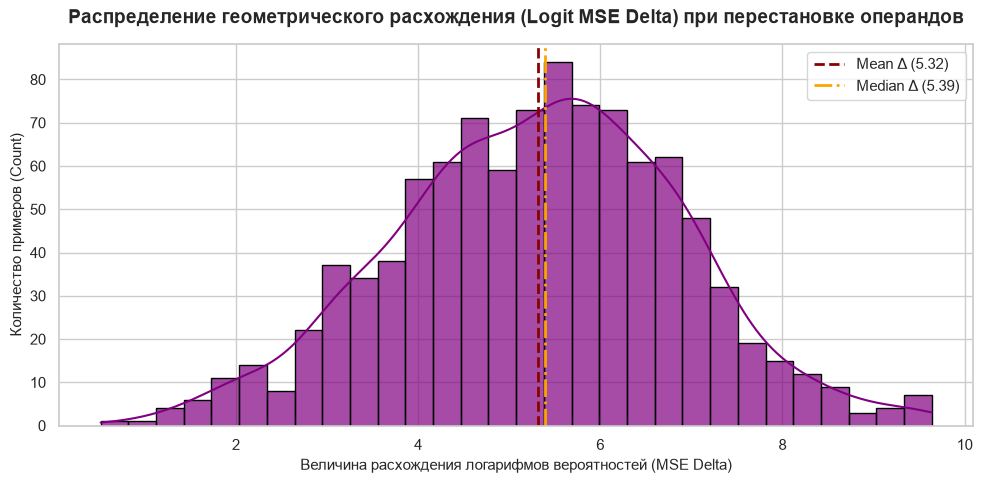

ТОП-3 НАИБОЛЕЕ СИММЕТРИЧНЫХ ПРИМЕРОB:
------------------------------------------------------------
Промпт: 0 0 0 5 6 + 0 0 0 5 5 = <c1> 1 <c1> 1 <c0> 1 <c0> 0 <c0> 0 <c0> 0 | Δ = 0.5151
Промпт: 0 0 0 7 4 + 0 0 0 8 4 = <c0> 8 <c1> 5 <c0> 1 <c0> 0 <c0> 0 <c0> 0 | Δ = 0.9906
Промпт: 0 0 4 1 2 + 3 0 4 1 6 = <c0> 8 <c0> 2 <c0> 8 <c0> 0 <c0> 3 <c0> 0 | Δ = 1.1333

ТОП-3 НАИБОЛЕЕ АСИММЕТРИЧНЫХ ПРИМЕРОB:
------------------------------------------------------------
Промпт: 3 2 5 9 5 + 0 0 0 0 0 = <c0> 5 <c0> 9 <c0> 5 <c0> 2 <c0> 3 <c0> 0 | Δ = 9.6231
Промпт: 0 0 9 3 0 + 3 9 8 8 2 = <c0> 2 <c1> 1 <c1> 8 <c1> 0 <c0> 4 <c0> 0 | Δ = 9.6349
Промпт: 7 8 5 0 6 + 0 0 1 9 0 = <c0> 6 <c0> 9 <c0> 6 <c0> 8 <c0> 7 <c0> 0 | Δ = 9.6380


In [11]:
import numpy as np

deltas_np = np.array(individual_deltas)

best_indices = np.argsort(deltas_np)[:3]   # Топ-3 минимальных дельт
worst_indices = np.argsort(deltas_np)[-3:]  # Топ-3 максимальных дельт

plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

sns.histplot(deltas_np, kde=True, color="purple", bins=30, edgecolor="black", alpha=0.7)

plt.axvline(x=mean_delta, color="darkred", linestyle="--", linewidth=2, label=f"Mean Δ ({mean_delta:.2f})")
plt.axvline(x=np.median(deltas_np), color="orange", linestyle="-.", linewidth=2, label=f"Median Δ ({np.median(deltas_np):.2f})")

plt.title("Распределение геометрического расхождения (Logit MSE Delta) при перестановке операндов", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Величина расхождения логарифмов вероятностей (MSE Delta)", fontsize=11)
plt.ylabel("Количество примеров (Count)", fontsize=11)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("ТОП-3 НАИБОЛЕЕ СИММЕТРИЧНЫХ ПРИМЕРОB:")
print("-" * 60)
for idx in best_indices:
    p_norm = tokenizer.decode(batch_normal[idx].tolist()).split("<pad>")[0].strip()
    print(f"Промпт: {p_norm} | Δ = {deltas_np[idx]:.4f}")

print("\nТОП-3 НАИБОЛЕЕ АСИММЕТРИЧНЫХ ПРИМЕРОB:")
print("-" * 60)
for idx in worst_indices:
    p_norm = tokenizer.decode(batch_normal[idx].tolist()).split("<pad>")[0].strip()
    print(f"Промпт: {p_norm} | Δ = {deltas_np[idx]:.4f}")

In [ ]:
# Получили смещённое нормальное распределение. 
# Это доказывает, что абсолютная позиционная инвариантность отсутствует и модель фундаментально завязана на абсолютные позиции токенов в строке.
# В том числе это можно увидеть анализируя наиболее симметричные/ассиметричные примеры.
# В наиболее симметричных примерах складываются числа одного масштаба и структуры. В ассиметричных же наблюдается дисбалланс масштабов.

In [ ]:
# Вывод:
# Модель освоила сложение на функциональном уровне - всегда выдает верный ответ. 
# Однако трансформер остался позиционно-зависимым вычислителем, для которого перестановка местами большого и маленького числа кардинально меняет внутренний маршрут вычислений.